
# K-Means Clustering: Theory and Application on Iris Dataset

## 1. What is K-Means?

K-Means is an unsupervised machine learning algorithm used for clustering data into K distinct groups.

The goal is to minimize the **within-cluster sum of squares (WCSS)**, also called inertia.

## 2. Objective Function

K-Means minimizes:

$J = Σ Σ || x_i - μ_j ||$^2

Where:
- x_i = data point
- μ_j = centroid of cluster j
- || · ||² = squared Euclidean distance

## 3. Algorithm Steps

1. Initialize K centroids randomly.
2. Assign each data point to the nearest centroid.
3. Update centroids by computing the mean of assigned points.
4. Repeat steps 2–3 until convergence.

## 4. Important Hyperparameters

- n_clusters (K)
- init (random or k-means++)
- max_iter
- n_init


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris = load_iris()
X = iris.data[:, :2]  # Use first two features for visualization

X[:5]


array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6]])

In [5]:
#iris.data
X

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1],
       [5.4, 3.7],
       [4.8, 3.4],
       [4.8, 3. ],
       [4.3, 3. ],
       [5.8, 4. ],
       [5.7, 4.4],
       [5.4, 3.9],
       [5.1, 3.5],
       [5.7, 3.8],
       [5.1, 3.8],
       [5.4, 3.4],
       [5.1, 3.7],
       [4.6, 3.6],
       [5.1, 3.3],
       [4.8, 3.4],
       [5. , 3. ],
       [5. , 3.4],
       [5.2, 3.5],
       [5.2, 3.4],
       [4.7, 3.2],
       [4.8, 3.1],
       [5.4, 3.4],
       [5.2, 4.1],
       [5.5, 4.2],
       [4.9, 3.1],
       [5. , 3.2],
       [5.5, 3.5],
       [4.9, 3.6],
       [4.4, 3. ],
       [5.1, 3.4],
       [5. , 3.5],
       [4.5, 2.3],
       [4.4, 3.2],
       [5. , 3.5],
       [5.1, 3.8],
       [4.8, 3. ],
       [5.1, 3.8],
       [4.6, 3.2],
       [5.3, 3.7],
       [5. , 3.3],
       [7. , 3.2],
       [6.4, 3.2],
       [6.9,

## 5. Basic K-Means with K=3

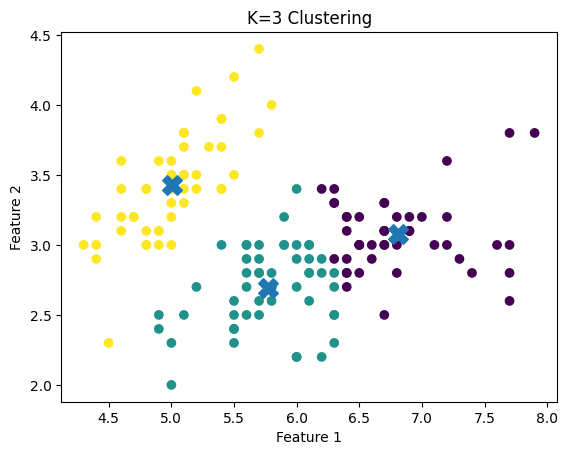

Inertia: 37.05070212765958


In [6]:

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)
plt.title("K=3 Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Inertia:", kmeans.inertia_)


## 6. Changing Number of Clusters (K)

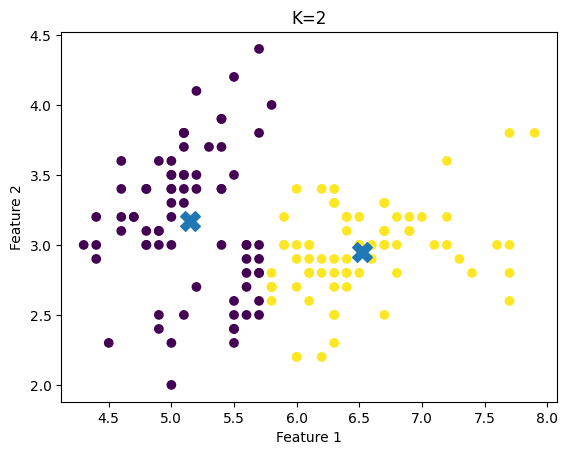

K=2, Inertia=58.44759246088194


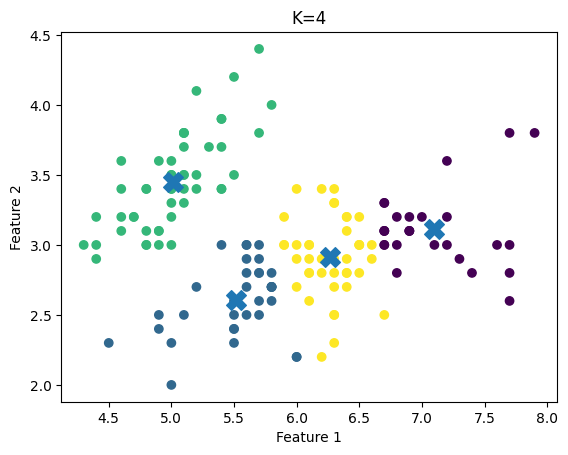

K=4, Inertia=28.413653173513797


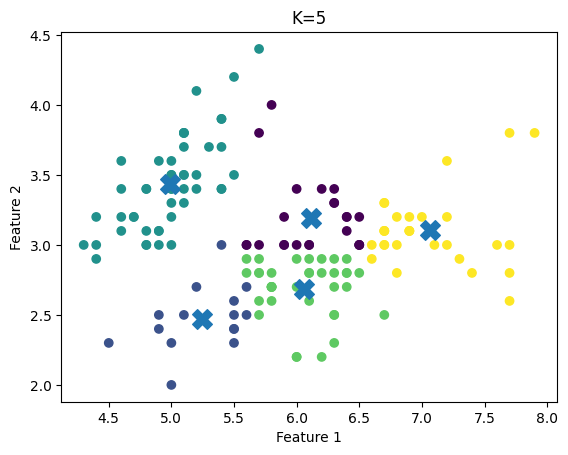

K=5, Inertia=26.932507558277603


In [3]:

for k in [2, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    labels = model.labels_
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker='X', s=200)
    plt.title(f"K={k}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
    
    print(f"K={k}, Inertia={model.inertia_}")


## 7. Effect of Different Initializations

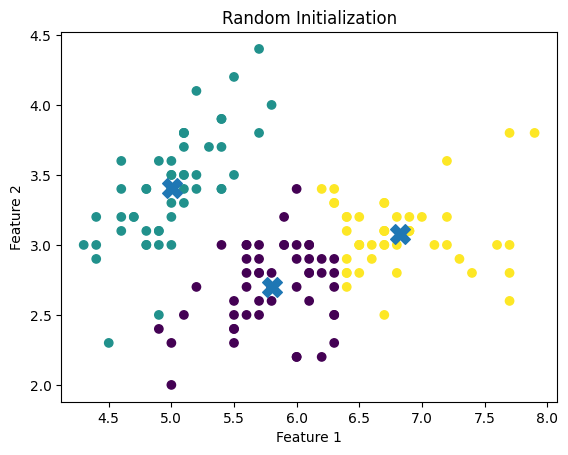

Random Init Inertia: 37.08627024722933


In [4]:

model_random = KMeans(n_clusters=3, init='random', n_init=1, random_state=42)
model_random.fit(X)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=model_random.labels_)
plt.scatter(model_random.cluster_centers_[:, 0], model_random.cluster_centers_[:, 1], marker='X', s=200)
plt.title("Random Initialization")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Random Init Inertia:", model_random.inertia_)


## 8. Observing Iterative Behavior (max_iter effect)

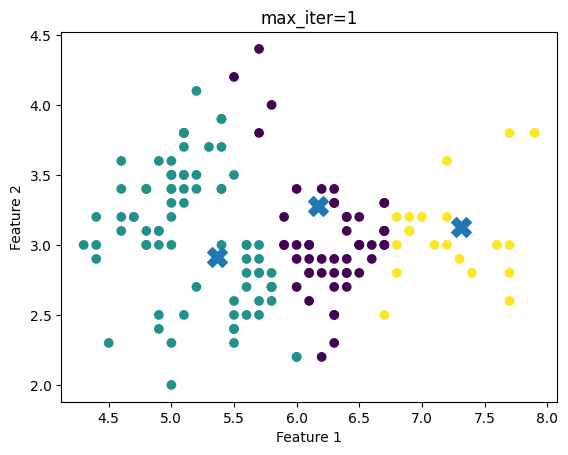

max_iter=1, Inertia=56.55989759587659


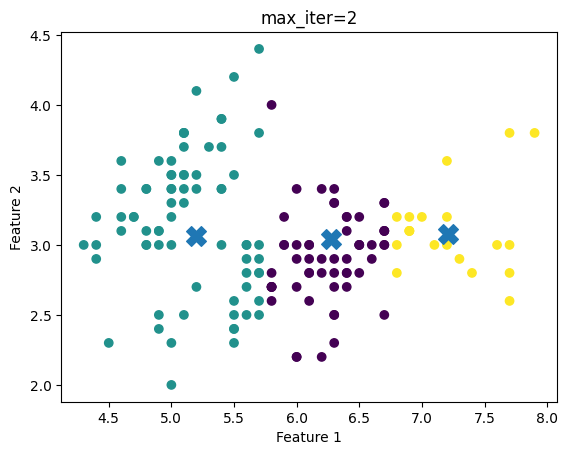

max_iter=2, Inertia=46.0466012618065


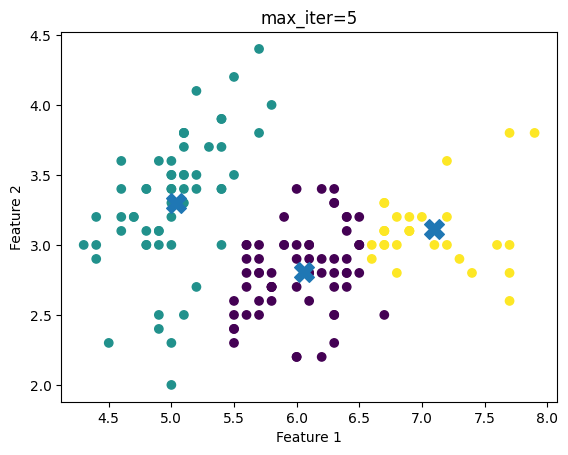

max_iter=5, Inertia=38.40532857405615


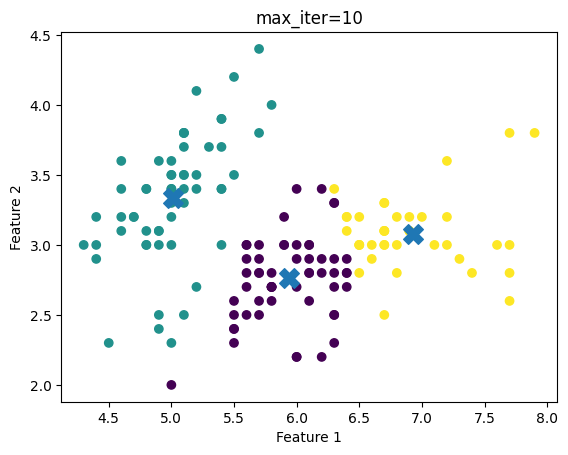

max_iter=10, Inertia=37.713613748304034


In [5]:

for max_iter in [1, 2, 5, 10]:
    model_iter = KMeans(n_clusters=3, max_iter=max_iter, n_init=1, init='random', random_state=42)
    model_iter.fit(X)
    
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=model_iter.labels_)
    plt.scatter(model_iter.cluster_centers_[:, 0], model_iter.cluster_centers_[:, 1], marker='X', s=200)
    plt.title(f"max_iter={max_iter}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
    
    print(f"max_iter={max_iter}, Inertia={model_iter.inertia_}")


## 9. Elbow Method

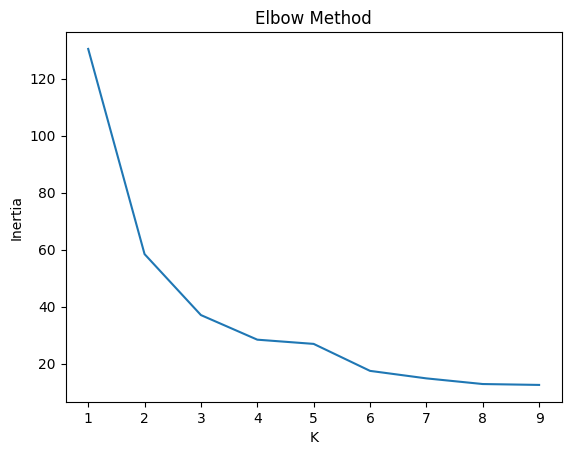

In [6]:

inertias = []
ks = range(1, 10)

for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure()
plt.plot(ks, inertias)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()
